# 3 — Polygon hierarchy (create_hbins + join_hbins)

Demonstrates the polygon path: build a nested regular grid over an AOI, join random point observations to the grid, and decompose the per-cell aggregated value across scales.

Requires the `[spatial]` extra: `pip install scalevar[spatial]`.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, box

from scalevar import scale_variance
from scalevar.spatial import create_hbins, join_hbins

rng = np.random.default_rng(20260424)

## Build a tiny AOI in a projected CRS

A 1 km × 1 km square in **British National Grid** (EPSG:27700). Geographic CRSes like EPSG:4326 are deliberately refused by `create_hbins` — see the project's crs-correction-note for why.

In [2]:
aoi = gpd.GeoDataFrame(
    geometry=[box(530_000, 180_000, 531_000, 181_000)],
    crs='EPSG:27700',
)
aoi

,geometry
0,"POLYGON ((531000 180000, 531000 181000, 530000..."


## Build nested hbins

Level 1 = 62.5 m cells, level 2 = 125 m, level 3 = 250 m, level 4 = 500 m.

In [3]:
hbins = create_hbins(aoi, base_cell_size=62.5, n_levels=4, base_level_factor=2)
hbins.groupby('level').size().rename('n_cells').to_frame()

,n_cells
level,
1,256
2,64
3,16
4,4


## Scatter random point observations and join them

In [4]:
n_pts = 400
minx, miny, maxx, maxy = aoi.total_bounds
xs = rng.uniform(minx, maxx, size=n_pts)
ys = rng.uniform(miny, maxy, size=n_pts)
# Give each point a value that covaries with its coarse location —
# i.e. variance mostly lives at the coarsest scale.
values = 100.0 * ((xs - minx) / (maxx - minx)) + 2.0 * rng.standard_normal(n_pts)
pts = gpd.GeoDataFrame(
    {'v': values},
    geometry=[Point(x, y) for x, y in zip(xs, ys, strict=True)],
    crs='EPSG:27700',
)

per_cell = join_hbins(pts, hbins, value_col='v', agg_fun='mean')
per_cell.head()

,id_level_1,id_level_2,id_level_3,id_level_4,v
0,95,279,327,337,96.269797
1,219,309,334,339,71.998686
2,174,303,331,339,90.738321
3,58,269,322,337,65.168231
4,5,258,321,336,34.930724


## Decompose

`id_level_1` is the finest cell; `id_level_{2..4}` are its ancestors. Pass these columns to `scale_variance`.

In [5]:
result = scale_variance(
    per_cell,
    value='v',
    id_cols=['id_level_1', 'id_level_2', 'id_level_3', 'id_level_4'],
)

print(f'TSS        = {result.total_ss:.2f}')
print(f'grand_mean = {result.grand_mean:.2f}')
print(f'total_df   = {result.total_df}')
result.components.round(4)

TSS        = 168780.57
grand_mean = 50.88
total_df   = 207


,level,scale,sum_squares,df,mean_square,ss_share,ms_share,ss_cumulative
0,1,NaN,2535.8023,144,17.6097,0.0150,0.0004,0.0150
1,2,NaN,7804.3207,48,162.5900,0.0462,0.0037,0.0613
2,3,NaN,35402.3575,12,2950.1965,0.2098,0.0668,0.2710
3,4,NaN,123038.0924,3,41012.6975,0.7290,0.9291,1.0000


## Visualize the finest level alongside variance-share

Because the values are a linear gradient in x, the variance should concentrate at the coarsest scale — confirming the scale decomposition recovers the structure you put in.

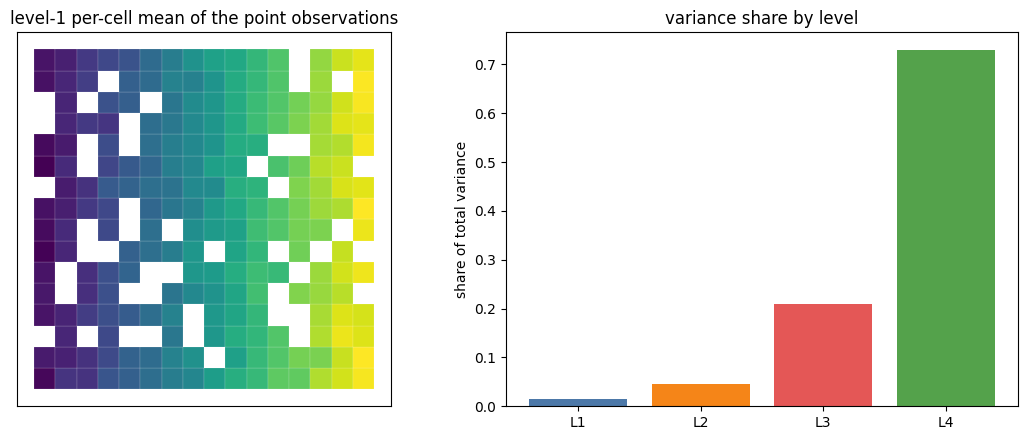

In [6]:
fig, (ax_map, ax_bars) = plt.subplots(1, 2, figsize=(11, 4.5),
                                      gridspec_kw={'width_ratios': [1, 1]})

lvl1 = hbins[hbins['level'] == 1].merge(per_cell[['id_level_1', 'v']],
                                       left_on='id', right_on='id_level_1')
lvl1.plot(column='v', ax=ax_map, cmap='viridis', edgecolor='white', linewidth=0.1)
ax_map.set_title('level-1 per-cell mean of the point observations')
ax_map.set_xticks([]); ax_map.set_yticks([])

ax_bars.bar(result.components['level'], result.components['ss_share'],
            color=['#4c78a8', '#f58518', '#e45756', '#54a24b'])
ax_bars.set_xticks(result.components['level'])
ax_bars.set_xticklabels(['L1', 'L2', 'L3', 'L4'])
ax_bars.set_ylabel('share of total variance')
ax_bars.set_title('variance share by level')
fig.tight_layout()
plt.show()

## CRS safety

`create_hbins` refuses geographic CRSes outright — the error message is the same across `create_hbins` and `scale_variance_raster` and will match the R sibling exactly in v0.2.

In [7]:
from scalevar import UnprojectedCRSError

bad_aoi = gpd.GeoDataFrame(geometry=[box(-0.1, 51.5, 0.1, 51.7)], crs='EPSG:4326')
try:
    create_hbins(bad_aoi, base_cell_size=0.01, n_levels=3)
except UnprojectedCRSError as e:
    print(str(e))

scalevar: unprojected or geographic CRS detected.
The scale variance method requires a projected CRS with linear units (e.g. meters), because it measures variance across cell sizes. Please project the input to an appropriate local projected CRS before calling this function — for example, British National Grid (EPSG:27700) in the UK, NAD83 / UTM zone N (EPSG:269NN) in the US, or any local equidistant projection suitable for your study area.
Received CRS: EPSG:4326
